# Import Libraries
# We load tools we need later.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Libraries loaded!")

Libraries loaded!


Step 2: Load Raw Data
Read the CSV file into a table called df.
# read_excelread_parquet

In [6]:
df = pd.read_csv('TSLA_messy.csv') 

print("Raw data loaded!")
print("Rows:", len(df), "| Columns:", len(df.columns))
df.head()

Raw data loaded!
Rows: 2967 | Columns: 7


,Date,Open,High,Low,Close,Adj Close,Volume
0,2011-09-16,4.956,5.168000,4.898000,5.160000,5.160000,7085500.0
1,2012-01-23,5.362,5.442000,5.320000,5.354000,5.354000,2973000.0
2,2021-01-13,852.76001,860.469971,832.000000,854.409973,854.409973,33312500.0
3,2011-06-28,5.558,5.650000,5.534000,5.622000,5.622000,4446000.0
4,2015-09-11,49.528,50.048000,48.945999,50.048000,50.048000,11754000.0


Step3: First Look - Size and Basic info

In [7]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Shape (rows, columns): (2967, 7)

Column names: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:
Date             str
Open             str
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume           str
dtype: object


Step 4: Check Missing Values
Questions: Are there empty cells?
If yes, we must fill or remove them

In [8]:
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing:", missing.sum())

Missing values in each column:
Date         0
Open         3
High         3
Low          3
Close        3
Adj Close    3
Volume       4
dtype: int64

Total missing: 19


Step5: Check Duplicate Rows
Question: Is the same row repeated?

In [9]:
dup_all = df.duplicated().sum()
dup_dates = df.duplicated(subset=['Date']).sum()
print(df.info())
print("Duplicate rows:", dup_all)
print("Duplicate dates:", dup_dates)

<class 'pandas.DataFrame'>
RangeIndex: 2967 entries, 0 to 2966
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2967 non-null   str    
 1   Open       2964 non-null   str    
 2   High       2964 non-null   float64
 3   Low        2964 non-null   float64
 4   Close      2964 non-null   float64
 5   Adj Close  2964 non-null   float64
 6   Volume     2963 non-null   str    
dtypes: float64(4), str(3)
memory usage: 162.4 KB
None
Duplicate rows: 8
Duplicate dates: 11


Step6: Fix Data Types
Date should be date type (not plain text).

In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print("Date column fixed!")
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())

ValueError: time data "2011-09-16" doesn't match format "%d-%m-%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [13]:
print(df['Date'].head(10))

0    2011-09-16
1    2012-01-23
2    2021-01-13
3    2011-06-28
4    2015-09-11
5    2021-04-09
6    2011-04-21
7    2018-04-20
8    2017-09-12
9    2016-04-07
Name: Date, dtype: str


In [14]:
print(df['Date'].tail(10))

2957    2021-04-01
2958    2019-08-19
2959    2015-02-10
2960    2018-11-13
2961    2012-05-14
2962    2019-02-25
2963    2018-11-08
2964    2012-03-06
2965    2013-10-30
2966    2020-08-26
Name: Date, dtype: str


In [15]:
print(df['Date'].dtype)

str


In [16]:
print(df['Date'].dtype)

str


In [17]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

ValueError: time data "04-04-2016" doesn't match format "%Y-%m-%d". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [18]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

DateParseError: Unknown datetime string format, unable to parse: not-a-date

In [19]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [20]:
print(df['Date'].isna().sum())

2


In [21]:
df[df['Date'].isna()]

,Date,Open,High,Low,Close,Adj Close,Volume
1550,NaT,1189.550049,1208.0,1123.050049,1149.589966,1149.589966,33416100.0
1740,NaT,1189.550049,1208.0,1123.050049,1149.589966,1149.589966,33416100.0


Both rows are duplicate of each other

In [22]:
df = df.dropna(subset=['Date'])

In [23]:
print(df['Date'].isna().sum())

0


In [24]:
df = df.dropna(subset=['Date'])

In [25]:
print(df['Date'].isna().sum())

0


Step7: Remove Duplicates and sort
even if duplicates are 0, it is a good practice.

In [26]:
before = len(df)

df = df.drop_duplicates(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

after = len(df)
print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Removed:     {before - after}")

Rows before: 2965
Rows after:  2955
Removed:     10


Step8: Logic Checks (Very Important)
Remove rows that are impossible in stock data:
* price should be > 0
* High should be >= low
*Volume should be > 0

In [27]:
before = len(df)

df = df[df['Close'] > 0]
df = df[df['Open'] > 0]
df = df[df['High'] >= df['Low']]
df = df[df['Volume'] > 0]

after = len(df)
print(f"Bad rows removed: {before - after}")
print(f"Clean rows left:  {after}")

TypeError: '>' not supported between instances of 'str' and 'int'

In [28]:
print(df.dtypes)

Date         datetime64[us]
Open                    str
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                  str
dtype: object


In [30]:
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

In [31]:
print(df.dtypes)

Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object


In [32]:
before = len(df)

df = df[df['Close'] > 0]
df = df[df['Open'] > 0]
df = df[df['High'] >= df['Low']]
df = df[df['Volume'] > 0]

after = len(df)

print(f"Bad rows removed: {before - after}")
print(f"Clean rows left:  {after}")

Bad rows removed: 23
Clean rows left:  2928


Step9: Create Helpful New columns
New columns can help analysis later

In [33]:
df['Year'] = df['Date'].dt.year
df['Price_Range'] = df['High'] - df['Low']

print("New columns added: Year, Price_Range")
df[['Date', 'Open', 'Close', 'Year', 'Price_Range']].head()

New columns added: Year, Price_Range


,Date,Open,Close,Year,Price_Range
0,2010-01-07,5.000,4.392,2010,1.130
1,2010-01-09,3.924,4.090,2010,0.218
2,2010-01-10,4.138,4.120,2010,0.088
3,2010-01-11,4.388,4.282,2010,0.288
4,2010-01-12,7.174,6.870,2010,0.594


Step10: Final Cleaning Check
After cleaning, always verify again.

In [34]:
print("=== CLEAN DATA REPORT ===")
print("Rows:", len(df))
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Negative Close prices:", (df['Close'] < 0).sum())
print("High < Low rows:", (df['High'] < df['Low']).sum())
print("\nBasic stats:")
df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()

=== CLEAN DATA REPORT ===
Rows: 2928
Missing values: 0
Duplicates: 0
Negative Close prices: 0
High < Low rows: 0

Basic stats:


,Open,High,Low,Close,Volume
count,2928.000000,2928.000000,2928.000000,2928.000000,2.928000e+03
mean,141.080788,144.188820,137.675469,141.016095,3.132859e+07
std,312.305031,318.328221,302.247221,307.312813,2.803442e+07
min,3.228000,3.326000,-48.127998,3.160000,5.925000e+05
25%,19.748499,20.504000,19.127500,19.841500,1.311250e+07
50%,46.688000,47.493000,45.820002,46.569000,2.487780e+07
75%,67.984501,69.131002,66.833002,67.932499,3.973875e+07
max,10417.099610,10546.700440,9950.000000,9956.500240,3.046940e+08


SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)? (1846068733.py, line 1)

Step 11: Quick Visual Check
Plot once to see if data looks normal

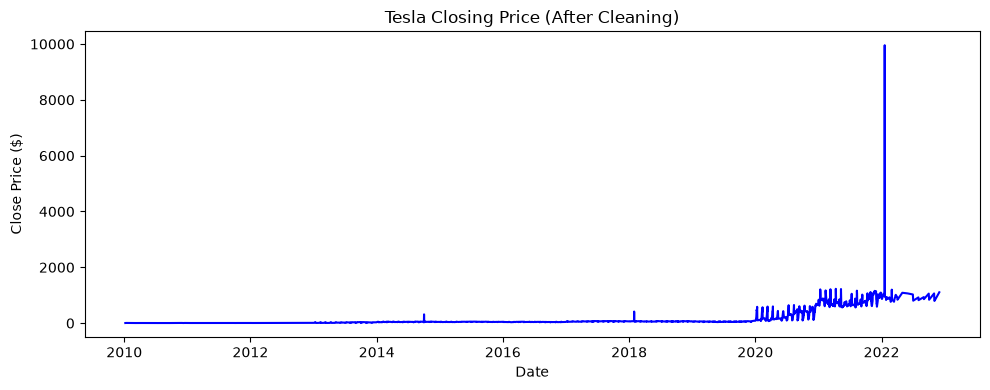

In [35]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Tesla Closing Price (After Cleaning)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.tight_layout()
plt.show()

Step12: Save Clean Data (Optional)

In [ ]:
df.to_csv('TSLA_clean.csv', index=False)
print("Saved as TSLA_clean.csv")